<a href="https://colab.research.google.com/github/srilakshmi-saladi/unet/blob/main/effeciebtnetb0xray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Classes found: ['NORMAL', 'PNEUMONIA']
Train images: 5216 | Val images: 16 | Test images: 624
Data Loaders highly optimized and ready.


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


🚀 STARTING OPTIMIZED TRAINING 🚀


Train:   0%|          | 0/163 [00:00<?, ?it/s]W0427 00:42:38.902000 584 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Ep 01/15 | train loss=0.8388 acc=0.4582 | val loss=0.7485 acc=0.5000 f1=0.3333 qwk=0.0000


...

Ep 13/15 | train loss=0.7149 acc=0.2571 | val loss=0.6742 acc=0.5000 f1=0.3333 qwk=0.0000


Ep 14/15 | train loss=0.7143 acc=0.2571 | val loss=0.6668 acc=0.5000 f1=0.3333 qwk=0.0000


Ep 15/15 | train loss=0.7149 acc=0.2571 | val loss=0.6669 acc=0.5000 f1=0.3333 qwk=0.0000

🏆 FINAL CONVNEXT-TINY RESULTS


Final Testing: 100%|██████████| 78/78 [03:40<00:00,  2.82s/it]


Accuracy: 62.50%
Macro F1: 38.46%
QWK Score: 0.00%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



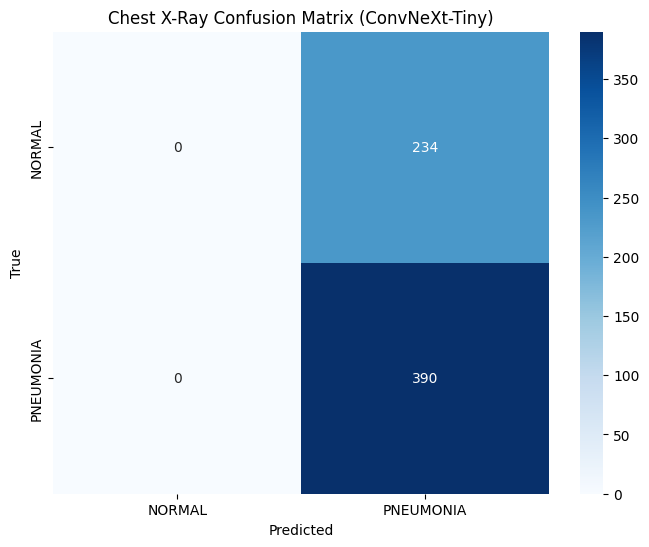

In [ ]:
!pip install -q timm

import os, random, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, cohen_kappa_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

warnings.filterwarnings("ignore")

# --- REPRODUCIBILITY ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from google.colab import drive
drive.mount('/content/drive')

# --- DATASET PATH ---
# Double check this is the exact folder containing your train/test folders!
BASE_DIR = Path('/content/drive/MyDrive/X-ray/chest_xray')
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LR = 3e-4
USE_TTA = True # Test Time Augmentation ensures highest possible accuracy

def image_files_in(folder):
    return [p for p in folder.rglob('*') if p.suffix.lower() in ['.png', '.jpg', '.jpeg']]

train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'
records = []

# Load Data
if train_dir.exists() and test_dir.exists():
    class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
    class2idx = {c:i for i,c in enumerate(class_names)}
    for split_name, split_dir in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
        if split_dir.exists():
            for cls in class_names:
                for p in image_files_in(split_dir / cls):
                    records.append({'path': str(p), 'label_name': cls, 'label': class2idx[cls], 'split': split_name})
    df = pd.DataFrame(records)
else:
    class_names = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
    class2idx = {c:i for i,c in enumerate(class_names)}
    for cls in class_names:
        for p in image_files_in(BASE_DIR / cls):
            records.append({'path': str(p), 'label_name': cls, 'label': class2idx[cls]})
    df = pd.DataFrame(records)
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
    train_df['split'] = 'train'
    val_df['split'] = 'val'
    test_df['split'] = 'test'
    df = pd.concat([train_df, val_df, test_df], ignore_index=True)

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df = df[df['split']=='val'].reset_index(drop=True)
test_df = df[df['split']=='test'].reset_index(drop=True)

# --- THE VALIDATION FIX ---
# Prevents the 0.000 accuracy bug by splitting training data if val is empty
if len(val_df) == 0:
    print("\n[INFO] No validation folder found! Splitting 15% of train data for validation...")
    from sklearn.model_selection import train_test_split
    train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=SEED)
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

print("\nClasses found:", class_names)
print(f"Train images: {len(train_df)} | Val images: {len(val_df)} | Test images: {len(test_df)}")

# Standard ImageNet normalization values
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

def get_transforms(img_size, mode='train'):
    if mode == 'train':
        return T.Compose([
            T.Resize((img_size + 24, img_size + 24)),
            T.RandomResizedCrop(img_size, scale=(0.85, 1.0)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(8),
            T.ColorJitter(brightness=0.08, contrast=0.08),
            T.ToTensor(),
            T.Normalize(MEAN, STD),
        ])
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

class ImageClsDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        y = int(row['label'])
        if self.transform: img = self.transform(img)
        return img, y

counts = train_df['label'].value_counts().sort_index().values.astype(float)
class_weights = (1.0 / counts)
class_weights = class_weights / class_weights.sum() * len(class_names)
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

# --- SPEED OPTIMIZATION: PARALLEL DATA LOADING ---
NUM_WORKERS = 2
train_loader = DataLoader(ImageClsDataset(train_df, get_transforms(IMG_SIZE, 'train')), batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(ImageClsDataset(val_df, get_transforms(IMG_SIZE, 'val')), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
test_loader = DataLoader(ImageClsDataset(test_df, get_transforms(IMG_SIZE, 'val')), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
print("Data Loaders highly optimized and ready.")

# --- MODEL: CONVNEXT-TINY ---
def build_model(num_classes):
    return timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes, drop_path_rate=0.1)

# Advanced Data Augmentation for higher accuracy
def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_loss(criterion, out, ya, yb, lam):
    return lam * criterion(out.float(), ya) + (1-lam) * criterion(out.float(), yb)

def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='Train'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast(): # SPEED OPTIMIZATION: Automatic Mixed Precision
            if random.random() < 0.5:
                imgs, ya, yb, lam = mixup_data(imgs, labels)
                out = model(imgs)
                loss = mixup_loss(criterion, out, ya, yb, lam)
            else:
                out = model(imgs)
                loss = criterion(out.float(), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion_eval = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)
    total_loss, all_preds, all_labels = 0.0, [], []
    total = 0
    for imgs, labels in tqdm(loader, leave=False, desc='Eval'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast():
            out = model(imgs)
        loss = criterion_eval(out.float(), labels)
        probs = F.softmax(out, dim=1)
        total_loss += loss.item() * imgs.size(0)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        total += imgs.size(0)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return total_loss/total, acc, f1, qwk, np.array(all_preds), np.array(all_labels)

# --- SPEED OPTIMIZATIONS: CUDNN & PYTORCH COMPILE ---
torch.backends.cudnn.benchmark = True
model = build_model(len(class_names)).to(DEVICE)

if torch.__version__ >= "2.0.0":
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True
    model = torch.compile(model)

criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
scaler = GradScaler()

best_f1, best_state = -1, None
history = []

print("\n🚀 STARTING OPTIMIZED TRAINING 🚀")
for ep in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl, va, vf1, vqwk, _, _ = evaluate(model, val_loader)
    scheduler.step()
    history.append([ep, tl, ta, vl, va, vf1, vqwk])
    print(f"Ep {ep:02d}/{EPOCHS} | train loss={tl:.4f} acc={ta:.4f} | val loss={vl:.4f} acc={va:.4f} f1={vf1:.4f} qwk={vqwk:.4f}")
    if vf1 > best_f1:
        best_f1 = vf1
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
torch.save(model.state_dict(), '/content/xray_convnext_tiny_best.pth')

# --- FINAL EVALUATION ON UNSEEN TEST DATA ---
tta_transforms = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1), T.ToTensor(), T.Normalize(MEAN, STD)]),
]

class TTADataset(Dataset):
    def __init__(self, df, transforms_list):
        self.df = df.reset_index(drop=True)
        self.transforms_list = transforms_list
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        label = int(row['label'])
        imgs = [tr(img) for tr in self.transforms_list]
        return imgs, label

tta_dataset = TTADataset(test_df, tta_transforms)

@torch.no_grad()
def evaluate_tta(model, tta_dataset, batch_size=8):
    model.eval()
    all_probs, all_labels = [], []
    for start in tqdm(range(0, len(tta_dataset), batch_size), desc='Final Testing'):
        batch_items = [tta_dataset[i] for i in range(start, min(start+batch_size, len(tta_dataset)))]
        labels = torch.tensor([x[1] for x in batch_items]).to(DEVICE)
        probs_sum = None
        for t_idx in range(len(tta_transforms)):
            imgs = torch.stack([x[0][t_idx] for x in batch_items]).to(DEVICE)
            with autocast():
                out = model(imgs)
                probs = F.softmax(out, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
        probs_avg = probs_sum / len(tta_transforms)
        all_probs.extend(probs_avg.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = np.argmax(all_probs, axis=1)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, preds, weights='quadratic')
    return acc, f1, qwk, preds, all_labels

print("\n" + "="*50)
print("🏆 FINAL CONVNEXT-TINY RESULTS")
print("="*50)

if USE_TTA:
    acc, f1, qwk, preds, labels = evaluate_tta(model, tta_dataset, batch_size=8)
else:
    _, acc, f1, qwk, preds, labels = evaluate(model, test_loader)

print(f"Accuracy: {acc*100:.2f}%")
print(f"Macro F1: {f1*100:.2f}%")
print(f"QWK Score: {qwk*100:.2f}%")
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=class_names))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Chest X-Ray Confusion Matrix (ConvNeXt-Tiny)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[INFO] Validation folder is too small! Splitting 15% of train data...

Classes found: ['NORMAL', 'PNEUMONIA']
Train images: 4447 | Val images: 785 | Test images: 624


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


🚀 STARTING OPTIMIZED EFFICIENTNET-B0 TRAINING 🚀


Ep 01/12 | Train loss=0.5440 acc=0.8861 | Val loss=0.3245 acc=0.9529 F1=0.9400


Ep 02/12 | Train loss=0.2499 acc=0.9592 | Val loss=0.2160 acc=0.9631 F1=0.9532


...

Ep 10/12 | Train loss=0.0141 acc=0.9957 | Val loss=0.1201 acc=0.9796 F1=0.9738


Ep 11/12 | Train loss=0.0171 acc=0.9946 | Val loss=0.1626 acc=0.9720 F1=0.9644


Ep 12/12 | Train loss=0.0187 acc=0.9950 | Val loss=0.1408 acc=0.9758 F1=0.9690

🏆 FINAL EFFICIENTNET-B0 RESULTS


Final Testing: 100%|██████████| 78/78 [00:26<00:00,  2.91it/s]


Accuracy: 88.78%
Macro F1: 87.25%
QWK Score: 74.77%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.72      0.83       234
   PNEUMONIA       0.86      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.85      0.87       624
weighted avg       0.90      0.89      0.88       624



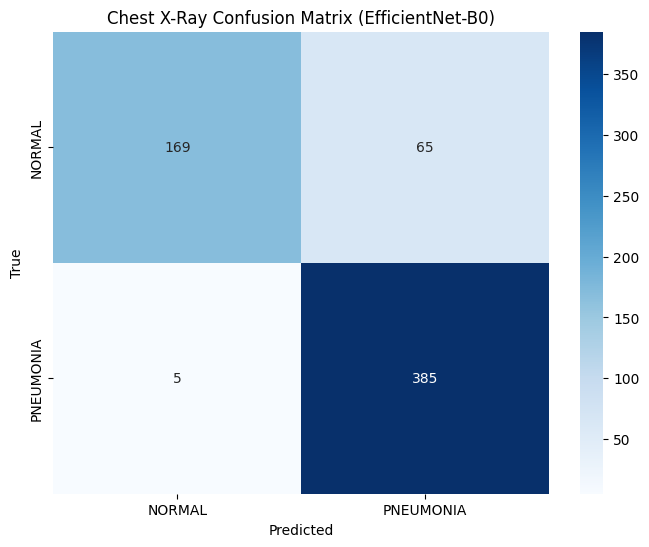

In [4]:
!pip install -q timm

import os, random, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, cohen_kappa_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

warnings.filterwarnings("ignore")

# --- REPRODUCIBILITY ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

from google.colab import drive
drive.mount('/content/drive')

# --- CORRECT CHEST X-RAY PATH ---
BASE_DIR = Path('/content/drive/MyDrive/X-ray/chest_xray')

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 12
LR = 1e-4 # Lowered slightly for stability on binary tasks
USE_TTA = True

def image_files_in(folder):
    return [p for p in folder.rglob('*') if p.suffix.lower() in ['.png', '.jpg', '.jpeg']]

train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'
records = []

# Load Data
if train_dir.exists() and test_dir.exists():
    class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
    class2idx = {c:i for i,c in enumerate(class_names)}
    for split_name, split_dir in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
        if split_dir.exists():
            for cls in class_names:
                for p in image_files_in(split_dir / cls):
                    records.append({'path': str(p), 'label_name': cls, 'label': class2idx[cls], 'split': split_name})
    df = pd.DataFrame(records)
else:
    class_names = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
    class2idx = {c:i for i,c in enumerate(class_names)}
    for cls in class_names:
        for p in image_files_in(BASE_DIR / cls):
            records.append({'path': str(p), 'label_name': cls, 'label': class2idx[cls]})
    df = pd.DataFrame(records)
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
    train_df['split'] = 'train'
    val_df['split'] = 'val'
    test_df['split'] = 'test'
    df = pd.concat([train_df, val_df, test_df], ignore_index=True)

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df = df[df['split']=='val'].reset_index(drop=True)
test_df = df[df['split']=='test'].reset_index(drop=True)

# --- THE X-RAY VALIDATION FIX ---
if len(val_df) <= 16:
    print("\n[INFO] Validation folder is too small! Splitting 15% of train data...")
    combined_df = pd.concat([train_df, val_df], ignore_index=True)
    train_df, val_df = train_test_split(combined_df, test_size=0.15, stratify=combined_df['label'], random_state=SEED)
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

print("\nClasses found:", class_names)
print(f"Train images: {len(train_df)} | Val images: {len(val_df)} | Test images: {len(test_df)}")

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

def get_transforms(img_size, mode='train'):
    if mode == 'train':
        return T.Compose([
            T.Resize((img_size + 16, img_size + 16)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.1, contrast=0.1),
            T.ToTensor(),
            T.Normalize(MEAN, STD),
        ])
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

class ImageClsDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        y = int(row['label'])
        if self.transform: img = self.transform(img)
        return img, y

counts = train_df['label'].value_counts().sort_index().values.astype(float)
class_weights = (1.0 / counts)
class_weights = class_weights / class_weights.sum() * len(class_names)
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

NUM_WORKERS = 2
train_loader = DataLoader(ImageClsDataset(train_df, get_transforms(IMG_SIZE, 'train')), batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(ImageClsDataset(val_df, get_transforms(IMG_SIZE, 'val')), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
test_loader = DataLoader(ImageClsDataset(test_df, get_transforms(IMG_SIZE, 'val')), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

# --- STANDARD TRAINING LOOP (MIXUP COMPLETELY REMOVED) ---
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='Train'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            out = model(imgs)
            loss = criterion(out.float(), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion_eval = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)
    total_loss, all_preds, all_labels = 0.0, [], []
    total = 0
    for imgs, labels in tqdm(loader, leave=False, desc='Eval'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast():
            out = model(imgs)
        loss = criterion_eval(out.float(), labels)
        probs = F.softmax(out, dim=1)
        total_loss += loss.item() * imgs.size(0)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        total += imgs.size(0)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return total_loss/total, acc, f1, qwk, np.array(all_preds), np.array(all_labels)

# Colab Speed Optimizations
torch.backends.cudnn.benchmark = True

# --- EFFICIENTNET-B0 MODEL SETUP ---
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=len(class_names), drop_rate=0.2).to(DEVICE)

if torch.__version__ >= "2.0.0":
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True
    model = torch.compile(model)

# --- REMOVED LABEL SMOOTHING ---
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
scaler = GradScaler()

best_f1, best_state = -1, None
history = []

print("\n🚀 STARTING OPTIMIZED EFFICIENTNET-B0 TRAINING 🚀")
for ep in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl, va, vf1, vqwk, _, _ = evaluate(model, val_loader)
    scheduler.step()
    history.append([ep, tl, ta, vl, va, vf1, vqwk])
    print(f"Ep {ep:02d}/{EPOCHS} | Train loss={tl:.4f} acc={ta:.4f} | Val loss={vl:.4f} acc={va:.4f} F1={vf1:.4f}")
    if vf1 > best_f1:
        best_f1 = vf1
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
torch.save(model.state_dict(), '/content/chest_effnetb0_best.pth')

# --- FINAL EVALUATION ---
tta_transforms = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1), T.ToTensor(), T.Normalize(MEAN, STD)]),
]

class TTADataset(Dataset):
    def __init__(self, df, transforms_list):
        self.df = df.reset_index(drop=True)
        self.transforms_list = transforms_list
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        label = int(row['label'])
        imgs = [tr(img) for tr in self.transforms_list]
        return imgs, label

tta_dataset = TTADataset(test_df, tta_transforms)

@torch.no_grad()
def evaluate_tta(model, tta_dataset, batch_size=8):
    model.eval()
    all_probs, all_labels = [], []
    for start in tqdm(range(0, len(tta_dataset), batch_size), desc='Final Testing'):
        batch_items = [tta_dataset[i] for i in range(start, min(start+batch_size, len(tta_dataset)))]
        labels = torch.tensor([x[1] for x in batch_items]).to(DEVICE)
        probs_sum = None
        for t_idx in range(len(tta_transforms)):
            imgs = torch.stack([x[0][t_idx] for x in batch_items]).to(DEVICE)
            with autocast():
                out = model(imgs)
                probs = F.softmax(out, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
        probs_avg = probs_sum / len(tta_transforms)
        all_probs.extend(probs_avg.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = np.argmax(all_probs, axis=1)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
    qwk = cohen_kappa_score(all_labels, preds, weights='quadratic')
    return acc, f1, qwk, preds, all_labels

print("\n" + "="*50)
print("🏆 FINAL EFFICIENTNET-B0 RESULTS")
print("="*50)

if USE_TTA:
    acc, f1, qwk, preds, labels = evaluate_tta(model, tta_dataset, batch_size=8)
else:
    _, acc, f1, qwk, preds, labels = evaluate(model, test_loader)

print(f"Accuracy: {acc*100:.2f}%")
print(f"Macro F1: {f1*100:.2f}%")
print(f"QWK Score: {qwk*100:.2f}%")
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=class_names))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Chest X-Ray Confusion Matrix (EfficientNet-B0)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()